# P4 - Réaliser une étude de Santé Publique avec Python

## Introduction

**Contexte** :

Ce projet s’appuie sur des données issues de la FAO. Il mobilise quatre jeux de données afin d’analyser la disponibilité alimentaire, la sous-nutrition, l’aide alimentaire et la population à l’échelle mondiale.

**Objectif** :

Réaliser différentes analyses sur la période 2013–2017 à partir des données disponibles afin d'étudier la problématique de la faim dans le monde.

**Méthodologie** :

Le travail est structuré en deux étapes :

**Notebook N1** : analyse exploratoire des fichiers bruts afin de préparer les données à l'analyse. Cette étape comprend le nettoyage des données, la gestion des valeurs manquantes et des doublons, la vérification des types de données, la standardisation des variables textuelles ainsi que la création de nouvelles variables dérivées.

**Notebook N2** : analyse des fichiers transformés afin de répondre à différentes questions relatives à l’accès à l’alimentation, à la sous-nutrition et à la disponibilité alimentaire.

**Dans ce notebook** :

1. [Importation des données et configuration de l’environnement](#1-importation-des-librairies-et-chargement-des-fichiers)

2. [Chargement des données transformées](#2-chargement-des-fichiers-transformés)

3. [Analyse principale](#3-analyse)

4. [Analyses complémentaires](#4-analyses-complémentaires)

5. [Conclusion](#conclusion)

_____________

## 1. Importation des librairies

Importation des librairies et chargement des jeux de données dans des dataframes. Paramétrage des options d’affichage et de visualisation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#paramètres d'affichage numérique
pd.set_option('display.float_format', '{:.0f}'.format)

#paramètres visualisation
sns.set_theme(style='whitegrid')
sns.set_palette('Set2')

plt.rc('figure', figsize=(10,6))
plt.rc('axes', titlesize=14, titleweight='bold')

## 2. Chargement des fichiers transformés

In [4]:
df_aide_alimentaire = pd.read_csv('../data/data_cleaned/aide_alimentaire_cleaned.csv')
df_dispo_alimentaire = pd.read_csv('../data/data_cleaned/dispo_alimentaire_cleaned.csv')
df_population = pd.read_csv('../data/data_cleaned/population_cleaned.csv')
df_sous_nutrition = pd.read_csv('../data/data_cleaned/sous_nutrition_cleaned.csv')

_______________

## 3. Analyse

Résolution de 11 questions à partir des données préparées, avec calculs statistiques et visualisations lorsque nécessaire.

### 3.1 Proportion de personnes en sous nutrition

In [5]:
#jointure entre la table population et la table sous nutrition, en ciblant l'année 2017

#filtrer les tables avant la jointure

df_population_2017 = (
    df_population[
        df_population['Année']==2017
        ]
)

df_sous_nutrition_2017 = (
    df_sous_nutrition[
        df_sous_nutrition['annee_reference'] == 2017
        ]
)

#joindre les tables 

population_sous_nutrition_2017 = (
    df_population_2017
    .merge(
        df_sous_nutrition_2017, 
        left_on=['Zone','Année'],
        right_on=['Zone','annee_reference'],
        how='inner'
        )
)
population_sous_nutrition_2017.head()

,Zone,Année,Population,Année_intervalle,sous_nutrition,annee_debut,annee_fin,annee_reference
0,Afghanistan,2017,36296113,2016-2018,10500000,2016,2018,2017
1,Afrique Du Sud,2017,57009756,2016-2018,3100000,2016,2018,2017
2,Albanie,2017,2884169,2016-2018,100000,2016,2018,2017
3,Algérie,2017,41389189,2016-2018,1300000,2016,2018,2017
4,Allemagne,2017,82658409,2016-2018,0,2016,2018,2017


In [6]:
#Calcul et affichage du nombre de personnes en état de sous nutrition

total_sous_nutrition = (
    population_sous_nutrition_2017['sous_nutrition']
    .sum()
)
total_sous_nutrition_m = total_sous_nutrition / 1_000_000

print(f'Nombre total de personnes en état de sous-nutrition en 2017 \n{total_sous_nutrition_m} M')

Nombre total de personnes en état de sous-nutrition en 2017 
535.7 M


In [7]:
#proportion de personnes en sous-nutrition

total_population = (
    population_sous_nutrition_2017['Population']
    .sum()
)

total_population_md = (total_population / 1_000_000_000).round(1)

proportion = (
    (total_sous_nutrition / 
    total_population)*100
).round(2)

print(f'Le taux de sous-nutrition en 2017 est d\'environ {proportion}%,\nsur une population total de {total_population_md} Md')

Le taux de sous-nutrition en 2017 est d'environ 7.1%,
sur une population total de 7.5 Md


________________

### 3.2 Nombre théorique de personnes qui pourraient être nourries

**Combien mange en moyenne un être humain** ?

* Valeur de référence : 2300 kcal/personne/jour

(Moyenne de l'apport calorique journalier recommandé pour les femmes, de 2100 calories, et 2600 calories pour les hommes)

In [8]:
df_dispo_kcal_par_pays = (
    df_dispo_alimentaire
    .groupby('Zone')
    .agg(
        Dispo_kcal_personne_jour = (
            'Disponibilité alimentaire (Kcal/personne/jour)','sum'
            ))
            .reset_index()
)

df_dispo_kcal_population = (
    df_population_2017[['Zone','Population']]
    .merge(
        df_dispo_kcal_par_pays, 
        on='Zone'
        )
)
df_dispo_kcal_population['Dispo_kcal_total'] = (
    df_dispo_kcal_population['Population'] *
    df_dispo_kcal_population['Dispo_kcal_personne_jour']
)
df_dispo_kcal_population.head()

,Zone,Population,Dispo_kcal_personne_jour,Dispo_kcal_total
0,Afghanistan,36296113,2087,75749987831
1,Afrique Du Sud,57009756,3020,172169463120
2,Albanie,2884169,3188,9194730772
3,Algérie,41389189,3293,136294599377
4,Allemagne,82658409,3503,289552406727


In [9]:
# moyenne des calories disponibles mondialement par personne par jour en 2017
dispo_kcal_moyenne_mondiale = (
    df_dispo_kcal_population['Dispo_kcal_personne_jour']
    .mean()
).round()
dispo_kcal_moyenne_mondiale

np.float64(2842.0)

In [10]:
#Calcul du nombre d'humains pouvant être nourris selon reference calorique moyenne journalière

dispo_kcal_reference = 2300

personnes_pouvant_etre_nourries_md = (
    df_dispo_kcal_population['Dispo_kcal_total']
    .sum()
    /dispo_kcal_reference
    /1_000_000_000
    ).round(2)
personnes_pouvant_etre_nourries_md

np.float64(9.1)

In [11]:
#pourcentage de la population mondiale pouvant être nourrie
(personnes_pouvant_etre_nourries_md/total_population_md*100).round(2)

np.float64(121.33)

Résultat :

Avec la disponibilité alimentaire mondiale en 2017, il serait théoriquement possible de nourrir environ 9,1 milliards de personnes, soit 121% de la population mondiale, sur la base de 2300 kcal par personne et par jour. 

__________

### 3.3 Nombre théorique de personnes qui pourraient être nourries avec les produits végétaux

In [12]:
#Calcul du nombre de kcal disponible pour les végétaux
df_dispo_kcal_vegetaux = (
    df_dispo_alimentaire.loc[df_dispo_alimentaire['Origine'] == 'Vegetale']
    .groupby('Zone')
    .agg(
        Dispo_kcal_vegetaux = (
            'Disponibilité alimentaire (Kcal/personne/jour)','sum'
            ))
            .reset_index()
)
df_dispo_kcal_vegetaux_population = (
    df_dispo_kcal_vegetaux
    .merge(
        df_population_2017[['Zone','Population']],
        on='Zone'
    )
)
df_dispo_kcal_vegetaux_population['Dispo_kcal_total_vegetaux'] = (
    df_dispo_kcal_vegetaux_population['Dispo_kcal_vegetaux']*
    df_dispo_kcal_vegetaux_population['Population']
)
df_dispo_kcal_vegetaux_population.head()

,Zone,Dispo_kcal_vegetaux,Population,Dispo_kcal_total_vegetaux
0,Afghanistan,1871,36296113,67910027423
1,Afrique Du Sud,2533,57009756,144405711948
2,Albanie,2203,2884169,6353824307
3,Algérie,2915,41389189,120649485935
4,Allemagne,2461,82658409,203422344549


In [13]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
personnes_pouvant_etre_nourries_vegetaux_md = (
    df_dispo_kcal_vegetaux_population['Dispo_kcal_total_vegetaux']
    .sum()
    /dispo_kcal_reference
    /1_000_000_000
    ).round(2)
personnes_pouvant_etre_nourries_vegetaux_md

np.float64(7.5)

In [14]:
#pourcentage de la population mondiale pouvant être nourrie
(personnes_pouvant_etre_nourries_vegetaux_md/total_population_md*100).round(2)

np.float64(100.0)

Résultat :

La disponibilité alimentaire mondiale de produits végétaux en 2017 permettait théoriquement de nourrir environ 7,5 milliards de personnes, sur la base d'un besoin de 2300 kcal par jour, soit 100% de la population mondiale de cette année.

_________________

### 3.4 Utilisation de la disponibilité intérieure

In [15]:
#Calcul de la disponibilité totale

disponibilite_totale = (
    df_dispo_alimentaire['Disponibilité intérieure'].sum()
)

In [16]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 

cols_utilisations_conso = [
    'Aliments pour animaux', 
    'Autres Utilisations',
    'Nourriture', 
    'Pertes',
    'Semences',
    'Traitement'
    ]

resultats =[]

for col in cols_utilisations_conso :
    total_utilisations = (
        df_dispo_alimentaire[col]
        .sum()
    )
    
    proportion = (
        total_utilisations/
        disponibilite_totale
        *100
    ).round(2)

    resultats.append([col, proportion])

In [17]:
df_utilisation_dispo = (
    pd.DataFrame (
        resultats,
        columns=[
            'Utilisations', 
            'Disponibilite_%'
            ]
    )
)

df_utilisation_dispo_plt = (
    df_utilisation_dispo.sort_values(
        by='Disponibilite_%', 
        ascending=False
        )
)
df_utilisation_dispo_plt

,Utilisations,Disponibilite_%
2,Nourriture,50
5,Traitement,22
0,Aliments pour animaux,13
1,Autres Utilisations,9
3,Pertes,5
4,Semences,2


In [18]:
#vérification
df_utilisation_dispo['Disponibilite_%'].sum().round()

np.float64(100.0)

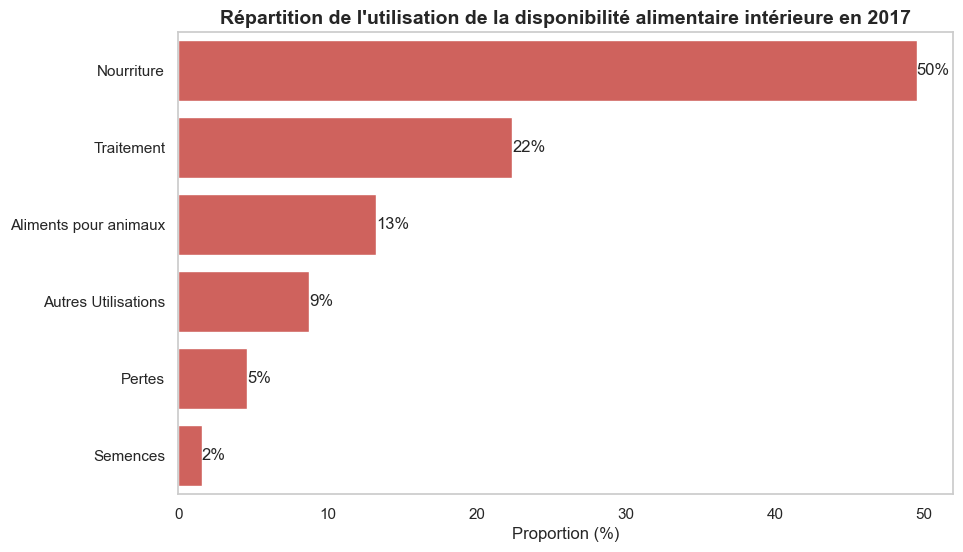

In [19]:
#visualisation des résultats
sns.set_palette('Spectral')

ax= sns.barplot(
    data=df_utilisation_dispo_plt,
    y='Utilisations',
    x='Disponibilite_%'  
)
ax.bar_label(
    ax.containers[0], 
    fmt='%.0f%%'
    )

plt.title('Répartition de l\'utilisation de la disponibilité alimentaire intérieure en 2017')
plt.xlabel('Proportion (%)')
plt.ylabel('')
plt.grid('')
plt.show()

Résultat :
* 50% de la disponibilité alimentaire intérieure totale est utilisée dans la nourriture ; 
* 22% dans le traitement ;
* 13% dans l'alimentation animale ;
* les 16% restant se distribuent entre pertes, semences et autres utilisations.

__________

### 3.5 Utilisation des céréales

In [20]:
#Création d'un dataframe avec les informations uniquement pour ces céréales

df_cereales = (
    df_dispo_alimentaire
    .loc[df_dispo_alimentaire['Categorie']=='Céréales']
).copy()

In [21]:
#Affichage de la proportion d'alimentation animale et humaine

df_cereales_utilisation = (
    df_cereales.pivot_table(
        index='Produit',
        values=[
            'Aliments pour animaux', 
            'Nourriture',
            'Disponibilité intérieure'
            ],
        aggfunc='sum'
    ).reset_index()
)

df_cereales_utilisation['Alimentation_animale_%'] = (
    df_cereales_utilisation['Aliments pour animaux']
    /
    df_cereales_utilisation['Disponibilité intérieure']
    *100
)

df_cereales_utilisation['Alimentation_humaine_%'] = (
    df_cereales_utilisation['Nourriture']
    /
    df_cereales_utilisation['Disponibilité intérieure']
    *100
)

df_cereales_utilisation[[
    'Produit', 
    'Alimentation_animale_%', 
    'Alimentation_humaine_%'
    ]]

,Produit,Alimentation_animale_%,Alimentation_humaine_%
0,Avoine,69,17
1,Blé,19,67
2,Céréales et autres,69,19
3,Maïs,57,13
4,Millet,11,77
5,Orge,66,5
6,Riz (équivalent blanchi),7,79
7,Seigle,49,33
8,Sorgho,43,41


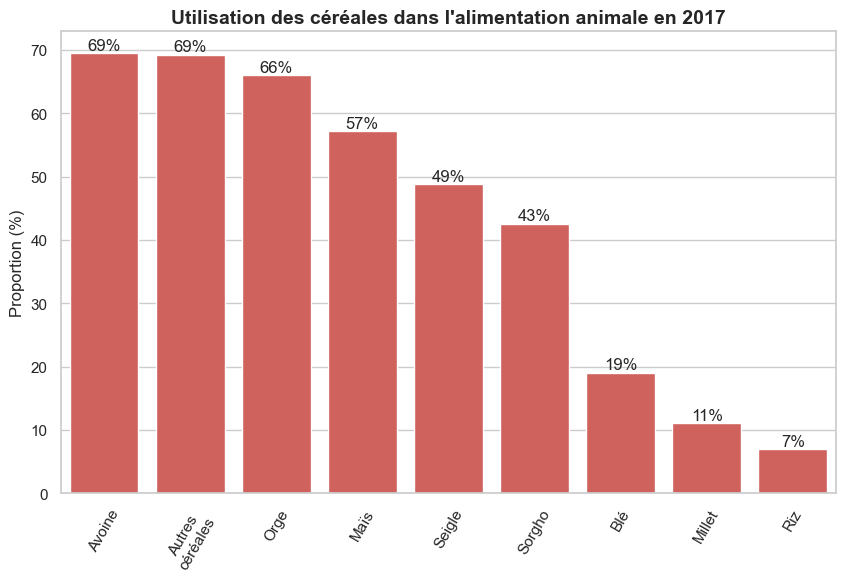

In [22]:
#visualisation des résultats

# Utilisation des céréales dans l'alimentation animale

df_cereales_alim_animal_plt = (
    df_cereales_utilisation
    .replace({'Produit':
    {'Céréales et autres':'Autres\ncéréales', 
    'Riz (équivalent blanchi)':'Riz'}
    })
    .sort_values(
        by='Alimentation_animale_%',
        ascending=False
        )
)

ax = sns.barplot(
    data=df_cereales_alim_animal_plt,
    x='Produit',
    y='Alimentation_animale_%'
    
)
ax.bar_label(
    ax.containers[0], 
    fmt='%.0f%%'
    )


plt.title('Utilisation des céréales dans l\'alimentation animale en 2017')
plt.ylabel('Proportion (%)')
plt.xlabel('')
plt.xticks(rotation=(60))
plt.show()

Interprétation :

La part destinée à l'alimentation animale varie de 7% pour le riz à 69% pour l'avoine. L'orge et le maïs sont également fortement utilisés pour l'alimentation animale (entre 66% et 57% de leur disponibilité intérieure), contrairement au blé (19%), au millet (11%) et au riz (7%), réservés plutôt à l'alimentation humaine.

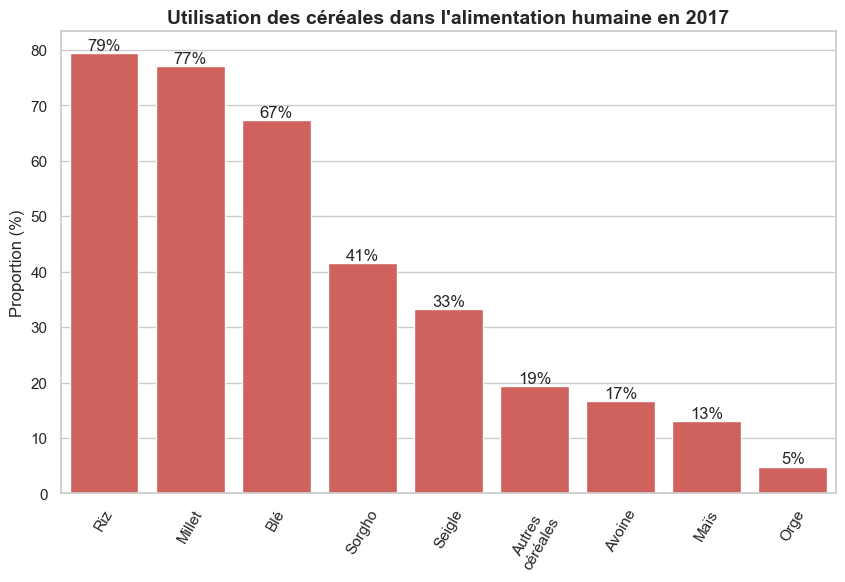

In [23]:
# Utilisation des céréales dans l'alimentation humaine

df_cereales_alim_humaine_plt = (
    df_cereales_utilisation
    .replace({'Produit':
    {'Céréales et autres':'Autres\ncéréales', 
    'Riz (équivalent blanchi)':'Riz'}
    })
    .sort_values(
        by='Alimentation_humaine_%',
        ascending=False
        )
)

ax = sns.barplot(
    data=df_cereales_alim_humaine_plt,
    x='Produit',
    y='Alimentation_humaine_%'
    
)
ax.bar_label(
    ax.containers[0], 
    fmt='%.0f%%'
    )

plt.title('Utilisation des céréales dans l\'alimentation humaine en 2017')
plt.ylabel('Proportion (%)')
plt.xlabel('')
plt.xticks(rotation=(60))
plt.show()

Interprétation :

La part destinée à l'alimentation humaine varie de 5% pour l'orge à 79% pour le riz. Le millet et le blé sont également fortement utilisés dans l'alimentation humaine (entre 77% et 67% de leur disponibilité intérieure), contrairement à l'avoine (17%), au maïs (13%) et l'orge (5%), consacré plutôt à l'alimentation animale.

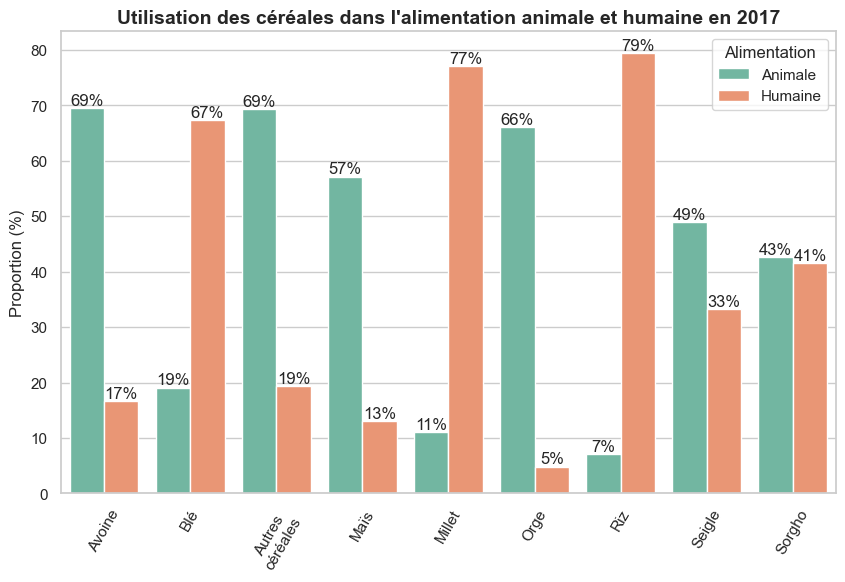

In [24]:
#graphique comparatif

df_cereales_utilisation_plot = (
    df_cereales_utilisation
    .replace({'Produit':
    {'Céréales et autres':'Autres\ncéréales', 
    'Riz (équivalent blanchi)':'Riz'}
    })
    .melt(
    id_vars='Produit',
    value_vars=['Alimentation_animale_%', 'Alimentation_humaine_%'],
    var_name='Type_utilisation',
    value_name='Pourcentage'
)
)

sns.set_palette('Set2')
ax = sns.barplot(
    data=df_cereales_utilisation_plot,
    x='Produit',
    y='Pourcentage',
    hue='Type_utilisation'
    
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%')

handles, labels = ax.get_legend_handles_labels()


plt.title('Utilisation des céréales dans l\'alimentation animale et humaine en 2017')
plt.ylabel('Proportion (%)')
plt.xlabel('')
plt.xticks(rotation=(60))
ax.legend(handles=handles, title='Alimentation', labels=['Animale', 'Humaine'])
plt.show()

**Conclusion** :

Les céréales se répartissent en deux groupes distincts selon leur usage principal :

* Le riz (79 %), le millet (77 %) et le blé (67 %) sont majoritairement destinés à l’alimentation humaine, avec de faibles proportions affectées à l’alimentation animale.
* À l’inverse, l’avoine (69 %), l’orge (66 %) et le maïs (57 %) sont principalement destinés à l’alimentation animale, avec de faibles parts utilisées pour l’alimentation humaine.

____________

### 3.6 Pays avec la proportion de personnes sous-alimentée la plus forte en 2017

In [25]:
population_sous_nutrition_par_pays_2017 = (
    population_sous_nutrition_2017[['Zone','Population','sous_nutrition']]
    .copy()
)

population_sous_nutrition_par_pays_2017['taux_sous_nutrition'] = (
    population_sous_nutrition_par_pays_2017['sous_nutrition']
    /population_sous_nutrition_par_pays_2017['Population']
    *100
    ).round(2)

top_10_pays_sous_alimentation_2017 = (
    population_sous_nutrition_par_pays_2017
    .sort_values(
        by='taux_sous_nutrition', 
        ascending=False
        )
    .head(10)
)
top_10_pays_sous_alimentation_2017

,Zone,Population,sous_nutrition,taux_sous_nutrition
78,Haïti,10982366,5300000,48
157,République Populaire Démocratique De Corée,25429825,12000000,47
108,Madagascar,25570512,10500000,41
103,Libéria,4702226,1800000,38
100,Lesotho,2091534,800000,38
183,Tchad,15016753,5700000,38
161,Rwanda,11980961,4200000,35
121,Mozambique,28649018,9400000,33
186,Timor-Leste,1243258,400000,32
0,Afghanistan,36296113,10500000,29


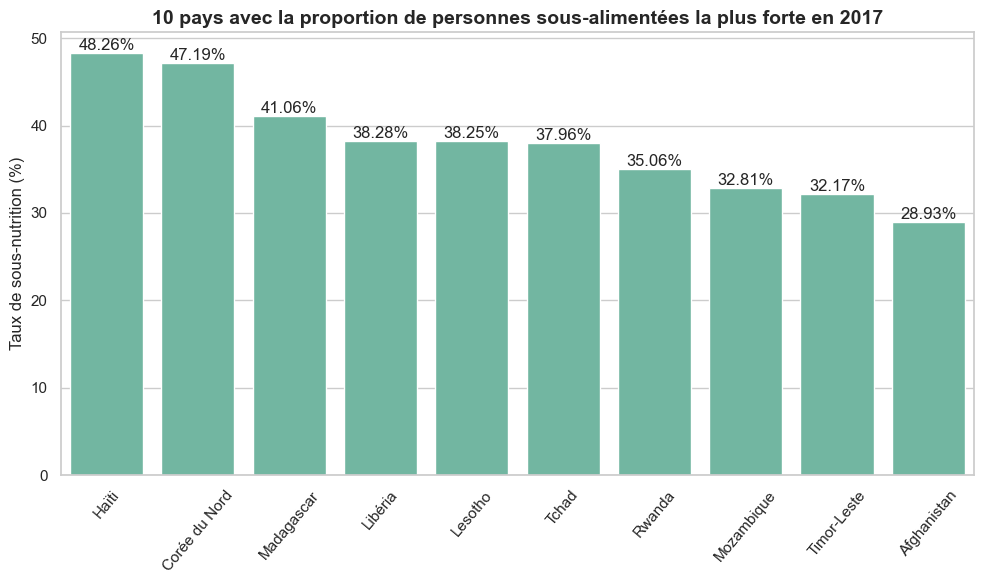

In [26]:
#visualisation des résultats

top_10_pays_sous_alimentation_2017_plt = (
    top_10_pays_sous_alimentation_2017
    .replace(
        {'Zone':{
            'République Populaire Démocratique De Corée':
            'Corée du Nord'
            }}
            )
)

ax = sns.barplot(
    data=top_10_pays_sous_alimentation_2017_plt,
    x='Zone',
    y='taux_sous_nutrition'
    )

ax.bar_label(
        ax.containers[0],
        fmt='%.2f%%'
    )

plt.title('10 pays avec la proportion de personnes sous-alimentées la plus forte en 2017')
plt.ylabel('Taux de sous-nutrition (%)')
plt.xlabel('')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

Près de 48% de la population d'Haïti en état de
sous-nutrition en 2017, l’un des taux les plus élevé au monde.

______________

### 3.7 Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013

In [27]:
aide_alimentaire_par_pays = pd.read_csv('../data/tables/aide_alimentaire_par_pays.csv')
aide_alimentaire_par_pays.head()

,Zone,Année,nb_produits,total_kg
0,Afghanistan,2013,8,128238000
1,Afghanistan,2014,8,57214000
2,Algérie,2013,11,35234000
3,Algérie,2014,10,18980000
4,Algérie,2015,10,17424000


In [28]:
total_aide_alimentaire_par_pays = (
    aide_alimentaire_par_pays
    .groupby('Zone').agg(total_aide_alimentaire_kg = ('total_kg','sum'))
    .reset_index()
)
top_10_pays_beneficiaires = (
    total_aide_alimentaire_par_pays
    .sort_values(
        by='total_aide_alimentaire_kg',
        ascending=False)
        .head(10)
)
top_10_pays_beneficiaires

,Zone,total_aide_alimentaire_kg
50,République Arabe Syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan Du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République Démocratique Du Congo,288502000
43,Niger,276344000


In [29]:
top_10_pays_beneficiaires_plot = (
    top_10_pays_beneficiaires
    .replace(
        {'Zone': {
            'République Arabe Syrienne':'Syrie',
            'Soudan Du Sud':'Soudan Sud',
            'République Démocratique Du Congo':'RD du Congo'
            }}
        )
)

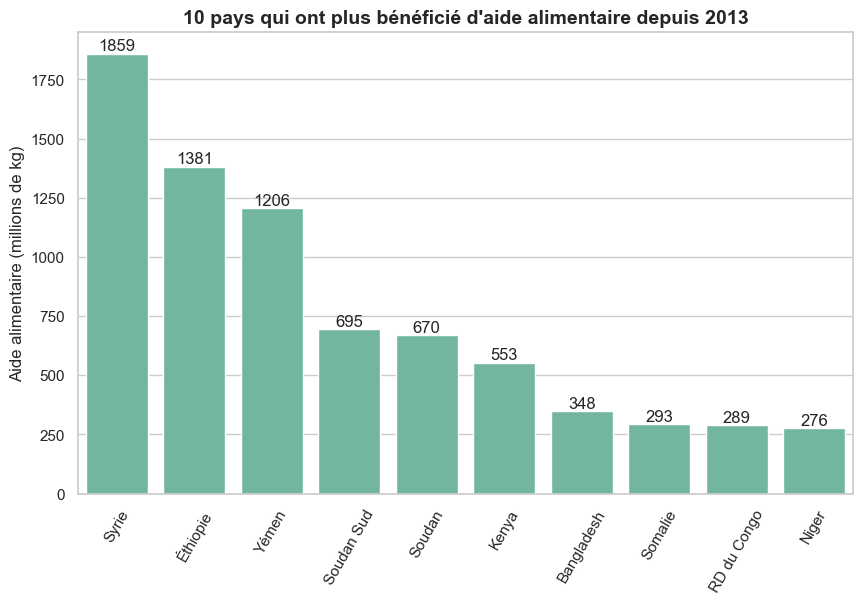

In [30]:
#visualisation des résultats
ax = sns.barplot(
    data=top_10_pays_beneficiaires_plot,
    x='Zone',
    y=top_10_pays_beneficiaires_plot['total_aide_alimentaire_kg']/1_000_000
    )

ax.bar_label(
    ax.containers[0], 
    fmt='%.0f'
    )

plt.title('10 pays qui ont plus bénéficié d\'aide alimentaire depuis 2013')
plt.ylabel('Aide alimentaire (millions de kg)')
plt.xlabel('')
plt.xticks(rotation=60)
plt.show()

Interprétation :
* L’aide alimentaire est très concentrée sur un petit nombre de pays (distribution asymétrique) ;
* Syrie domine largement, puis un second niveau (Éthiopie, Yémen), un bloc intermédiaire, un groupe bas (7–10).

_______________

### 3.8 Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016

In [31]:
subset_aide_alimentaire = (
    aide_alimentaire_par_pays[['Zone','Année','total_kg']]
)

total_aide_alimentaire_annuelle_par_pays = (
    subset_aide_alimentaire
    .groupby(['Zone','Année'])
    .agg(
        total_aide_alimentaire_kg = ('total_kg','sum')
        )
    .reset_index()
)

In [32]:
top_5_pays_beneficiaires = (
    top_10_pays_beneficiaires['Zone']
    .head(5)
)

evolution_top_5_pays_beneficiaires = (
    total_aide_alimentaire_annuelle_par_pays[
        total_aide_alimentaire_annuelle_par_pays['Zone']
        .isin(top_5_pays_beneficiaires)
        ].copy()
)
evolution_top_5_pays_beneficiaires

,Zone,Année,total_aide_alimentaire_kg
157,République Arabe Syrienne,2013,563566000
158,République Arabe Syrienne,2014,651870000
159,République Arabe Syrienne,2015,524949000
160,République Arabe Syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan Du Sud,2013,196330000
193,Soudan Du Sud,2014,450610000
194,Soudan Du Sud,2015,48308000


In [33]:
evolution_top_5_pays_beneficiaires['aide_millions_kg'] = (
    evolution_top_5_pays_beneficiaires['total_aide_alimentaire_kg'] / 1_000_000
)

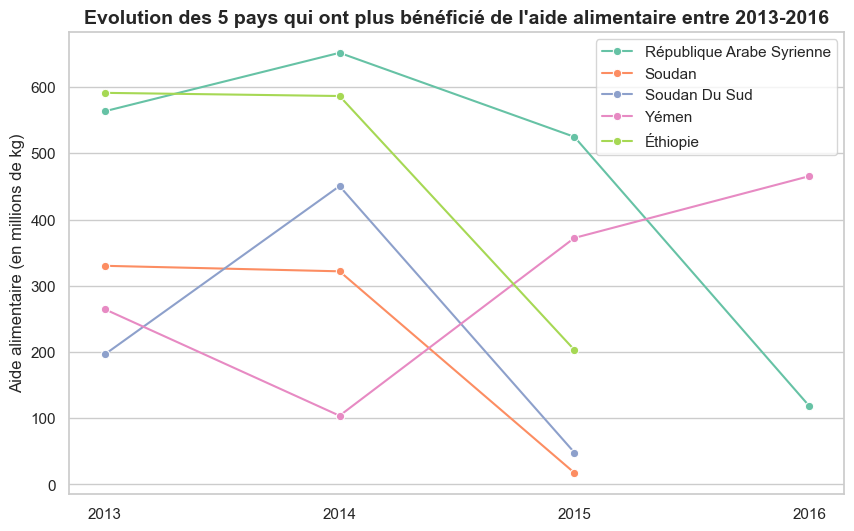

In [34]:
#visualisation des résultats

sns.lineplot(
    data=evolution_top_5_pays_beneficiaires, 
    x='Année',
    y='aide_millions_kg', 
    hue='Zone',
    marker='o'
    )

plt.title('Evolution des 5 pays qui ont plus bénéficié de l\'aide alimentaire entre 2013-2016')
plt.ylabel('Aide alimentaire (en millions de kg)')
plt.xlabel('')
plt.xticks(
    sorted(evolution_top_5_pays_beneficiaires['Année'].unique())
)
plt.grid(axis='x')
plt.legend()
plt.show()

Interprétation :

Le graphique montre une forte variation de l'aide alimentaire reçue par les cinq principaux bénéficiaires entre 2013-2016 :
* L'Ethiopie est le principal bénéficiaire en 2013, mais l'aide diminue fortement à partir de 2014 jusqu'à disparaître en 2015.
* À partir de 2014, la Syrie devient le premier bénéficiaire avant d'être dépassée par le Yémen en 2016. Ce dernier connaît la progression la plus marquée sur la période.
* Le Soudan du Sud se distingue par un pic de l'aide alimentaire en 2014. 
* Seuls la Syrie et le Yémen continuent de bénéficier d'une aide alimentaire jusqu'en 2016.

_____________

### 3.9 Pays avec le moins de disponibilité par habitant

In [35]:
dispo_alimentaire_kcal_personne_jour_par_pays = (
    df_dispo_alimentaire
    .groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)']
    .sum()
    .reset_index()
)
top_10_pays_moins_kcal_dipo_par_personne = (
    dispo_alimentaire_kcal_personne_jour_par_pays
    .sort_values(
        by='Disponibilité alimentaire (Kcal/personne/jour)', 
        ascending=False
        )
    .tail(10)
)
top_10_pays_moins_kcal_dipo_par_personne

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
154,Timor-Leste,2129
114,Ouganda,2126
167,Zimbabwe,2113
151,Tchad,2109
133,République Populaire Démocratique De Corée,2093
65,Haïti,2089
0,Afghanistan,2087
91,Madagascar,2056
166,Zambie,1924
128,République Centrafricaine,1879


In [36]:
top_10_pays_moins_kcal_dipo_par_personne.to_csv('../data/tables/top_moins_kcal.csv', index=False)

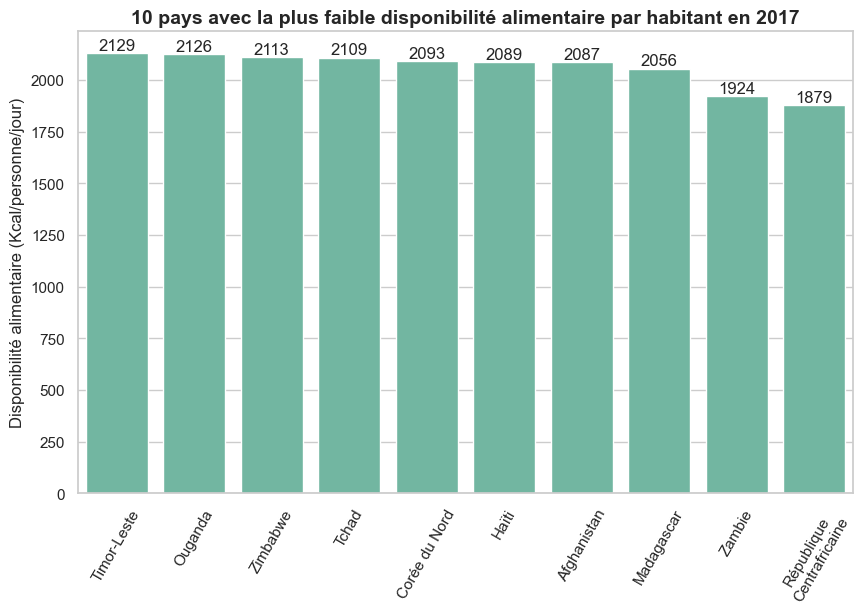

In [37]:
#visualisation des résultats

top_10_pays_moins_kcal_dipo_par_personne_plt = (
    top_10_pays_moins_kcal_dipo_par_personne
.replace(
    {'Zone':{
        'République Centrafricaine':
        'République\nCentrafricaine',
        'République Populaire Démocratique De Corée':
        'Corée du Nord'
        }}
        )
)

# Top 10 moins kcal
ax = sns.barplot(
    data=top_10_pays_moins_kcal_dipo_par_personne_plt,
    x='Zone',
    y='Disponibilité alimentaire (Kcal/personne/jour)'
    )
ax.bar_label(
    ax.containers[0],
    fmt='%.0f'
)

plt.title('10 pays avec la plus faible disponibilité alimentaire par habitant en 2017')
plt.xlabel('')
plt.xticks(rotation=60)

plt.show()

Interprétation :

* La République Centrafricaine et la Zambie disposent de moins de 2000 kcal par personne par jour.

____________

### 3.10 Pays avec le plus de disponibilité par habitant

In [38]:
top_10_pays_plus_kcal_dipo_par_personne = (
    dispo_alimentaire_kcal_personne_jour_par_pays
    .sort_values(
        by='Disponibilité alimentaire (Kcal/personne/jour)', 
        ascending=False
        )
    .head(10)
)
top_10_pays_plus_kcal_dipo_par_personne

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
11,Autriche,3770
16,Belgique,3737
159,Turquie,3708
171,États-Unis D'Amérique,3682
74,Israël,3610
72,Irlande,3602
75,Italie,3578
89,Luxembourg,3540
168,Égypte,3518
4,Allemagne,3503


In [39]:
top_10_pays_plus_kcal_dipo_par_personne.to_csv('../data/tables/top_plus_kcal.csv', index=False)

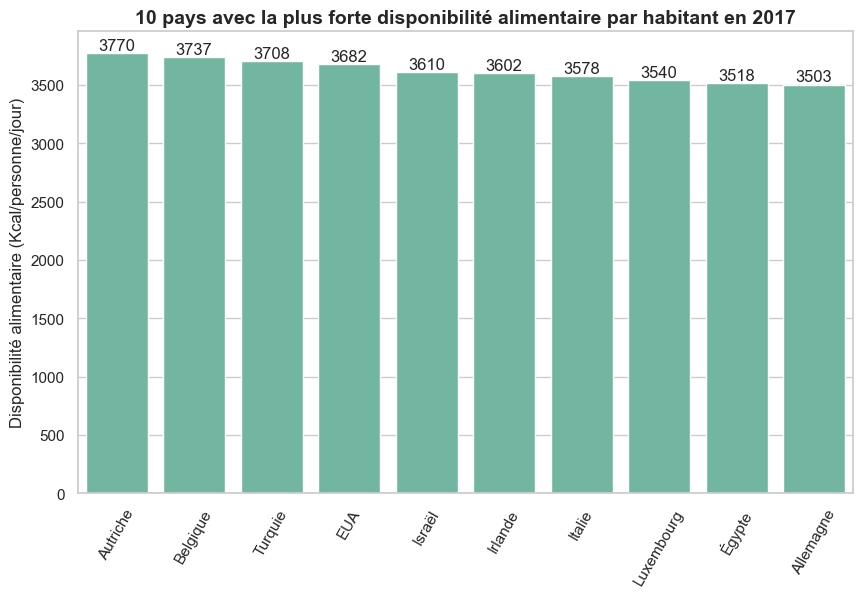

In [40]:
#visualisation des résultats

top_10_pays_plus_kcal_dipo_par_personne_plt = (
    top_10_pays_plus_kcal_dipo_par_personne
    .replace(
        {'Zone':
            {'États-Unis D\'Amérique': 
            'EUA'
            }}
    )
)

# Top 10 plus kcal
ax = sns.barplot(
    data=top_10_pays_plus_kcal_dipo_par_personne_plt,
    x='Zone',
    y='Disponibilité alimentaire (Kcal/personne/jour)'
    )

ax.bar_label(ax.containers[0], fmt='%.0f')

plt.title('10 pays avec la plus forte disponibilité alimentaire par habitant en 2017')
plt.xlabel('')
plt.xticks(rotation=60)

plt.show()

Interprétation :

* Tous les pays listés disposent de plus de 3500 kcal par personne et par jour ;
* Les trois premiers pays, à savoir l'Autriche, la Belgique et la Turquie, dépassent les 3700 kcal.

__________

### 3.11 Exemple de la Thaïlande pour le manioc

In [41]:
#sous-nutrition en Thaïlande en 2017 
sous_nutrition_thailande_2017 = (
    population_sous_nutrition_par_pays_2017[
        population_sous_nutrition_par_pays_2017['Zone']=='Thaïlande'
        ]
    )

In [42]:
# proportion exportee de manioc en fonction de la production
manioc_thailande = df_dispo_alimentaire[
    (df_dispo_alimentaire['Zone'] == 'Thaïlande') &
    (df_dispo_alimentaire['Produit'] == 'Manioc')
].copy()

manioc_thailande['Manioc_exportee_%'] = (
    manioc_thailande['Exportations - Quantité']/
    manioc_thailande['Production']
    *100
).round(1)

manioc_thailande['Importations_%'] = (
    manioc_thailande['Importations - Quantité']
    /manioc_thailande['Production']
    *100
).round(1)

manioc_thailande.transpose()

,13809
Zone,Thaïlande
Produit,Manioc
Origine,Vegetale
Aliments pour animaux,1800000000
Autres Utilisations,2081000000
Disponibilité alimentaire (Kcal/personne/jour),40
Disponibilité alimentaire en quantité (kg/personne/an),13
Disponibilité de matière grasse en quantité (g/personne/jour),0
Disponibilité de protéines en quantité (g/personne/jour),0
Disponibilité intérieure,6264000000


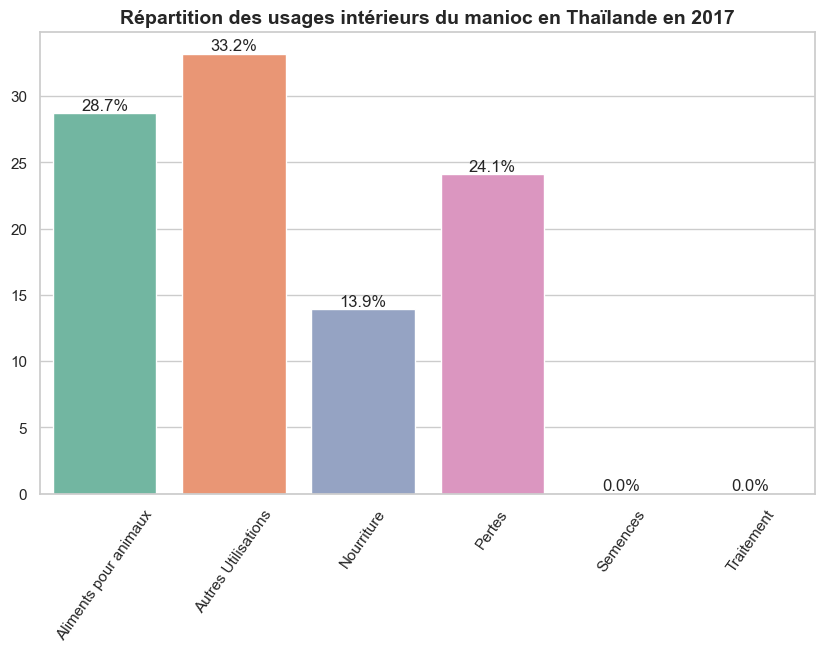

In [43]:
#visualisation des utilisations du manioc
utilisations_pct = (
    manioc_thailande[cols_utilisations_conso]
    .div(manioc_thailande['Disponibilité intérieure'], axis=0)
    * 100
).round(1)

ax = sns.barplot(data=utilisations_pct)

for container in ax.containers:
    ax.bar_label(
    container, 
    fmt='%.1f%%')

plt.title('Répartition des usages intérieurs du manioc en Thaïlande en 2017')
plt.ylabel('')
plt.xticks(rotation=55)
plt.show()

Ce graphique montre que :

* Une faible part du manioc est destinée à l'alimentation humaine (~14 %) ;
* une part importante sert à l'alimentation animale (28.7%) ;
* une autre part importante est utilisée à d'autres fins ;
* les pertes sont également élevées.

In [44]:
analyse_manioc_thailande_2017 = (
    sous_nutrition_thailande_2017
    .merge(
        manioc_thailande[
            ['Zone',
            'Exportations - Quantité', 
            'Production',
            'Manioc_exportee_%',
            'Importations_%']
            ], 
            on='Zone'
            )
    .merge(
        df_dispo_kcal_population[
            df_dispo_kcal_population['Zone'] == 'Thaïlande'
            ][['Zone','Dispo_kcal_personne_jour']],
            on='Zone'
            )
)

analyse_manioc_thailande_2017[['Population','sous_nutrition']] /= 1_000_000
analyse_manioc_thailande_2017[['Exportations - Quantité', 'Production']] /= 1_000_000_000

analyse_manioc_thailande_2017 = (
    analyse_manioc_thailande_2017
    .rename(columns={
        'Population':'Population (Millions)',
        'sous_nutrition':'Sous nutrition (Millions)',
        'taux_sous_nutrition':'Taux sous nutrition',
        'Exportations - Quantité':'Exportation manioc (Milliards de kg)',
        'Production':'Production manioc (Milliards de kg)',
        'Manioc_exportee_%':'Proportion exportee',
        'Dispo_kcal_personne_jour':'Disponibilité (kcal/personne/jour)'
        }
        )
)

analyse_manioc_thailande_2017.transpose()

,0
Zone,Thaïlande
Population (Millions),69
Sous nutrition (Millions),6
Taux sous nutrition,9
Exportation manioc (Milliards de kg),25
Production manioc (Milliards de kg),30
Proportion exportee,83
Importations_%,4
Disponibilité (kcal/personne/jour),2785


Résultat :

En 2017, la Thaïlande présente un taux de sous-alimentation d'environ 9%, tout en exportant 83% de sa production de manioc et malgré une disponibilité alimentaire moyenne de 2785 kcal par personne et par jour.

Bien que la production nationale soit importante, la Thaïlande importe également du manioc à hauteur de 4 % de sa production.

Conclusion :

La production de manioc en Thaïlande est principalement destinée à l'exportation, l'alimentation animale et d'autres usages, plutôt que vers l'alimentation humaine directe.

_____________

## 4. Analyses complémentaires

Analyses additionnelles permettant d’approfondir certains résultats ou d’explorer des aspects non couverts par les questions principales.

### 4.1 Relation disponibilité calorique et taux de sous-nutrition

#### 4.1.1 Les pays ayant davantage de calories disponibles ont-ils moins de sous-nutrition ?

In [45]:
population_sous_nutrition_dispo_kcal_2017 = (
    population_sous_nutrition_par_pays_2017
    .merge(
        dispo_alimentaire_kcal_personne_jour_par_pays,
        on='Zone'
    )
).copy()

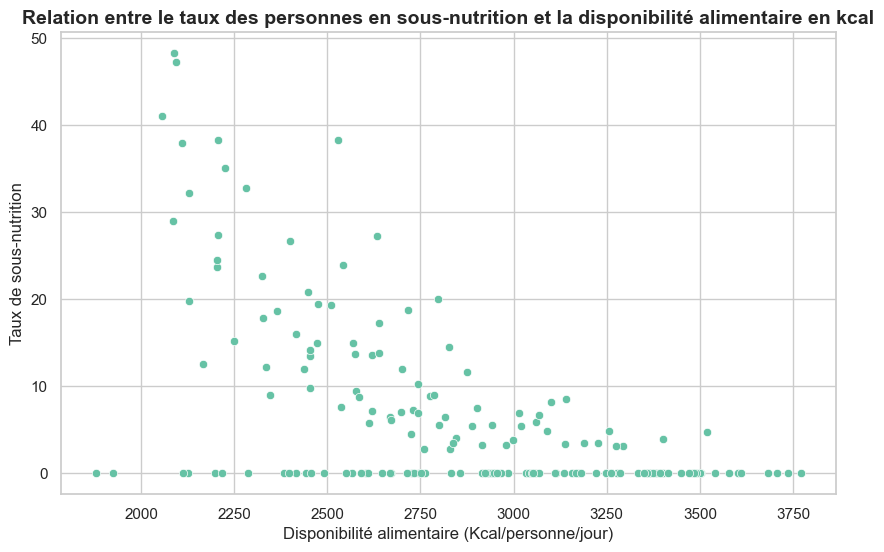

In [46]:
sns.scatterplot(
    data=population_sous_nutrition_dispo_kcal_2017, 
    y='taux_sous_nutrition', 
    x='Disponibilité alimentaire (Kcal/personne/jour)'
    )

plt.title('Relation entre le taux des personnes en sous-nutrition et la disponibilité alimentaire en kcal')
plt.ylabel('Taux de sous-nutrition')
plt.show()

* Une relation négative globale existe entre la disponibilité alimentaire et le taux de sous-nutrition, mais elle reste faible à modérée et n'est pas parfaitement linéaire.

Deux groupes observés : 
* Groupe principal : concentration de pays entre 2250 et 3000 kcal/personne/jour et 10 à 20% de sous-nutrition.
* Groupe sans sous-nutrition : groupe important de pays avec un taux de sous-nutrition nul malgré des niveaux de disponibilité alimentaire très variés, créant une accumulation de points sur l'axe horizontal.

In [47]:
pays_zero_sous_nutrition = (
    population_sous_nutrition_dispo_kcal_2017[
        population_sous_nutrition_dispo_kcal_2017["taux_sous_nutrition"] == 0
        ]
)

pays_zero_sous_nutrition.shape[0] / len(population_sous_nutrition_dispo_kcal_2017)*100

51.162790697674424

* 51% de la population étudiée présente un taux de sous-nutrition zéro.

* Ce groupe représentant plus de la moitié des observations, il est pertinent d'examiner si sa distribution de disponibilité alimentaire diffère de celle observée à l'échelle mondiale.

___________

#### 4.1.2 Comment la disponibilité alimentaire est-elle distribuée dans les pays sans sous-nutrition et en quoi cette distribution diffère-t-elle de la distribution mondiale ?

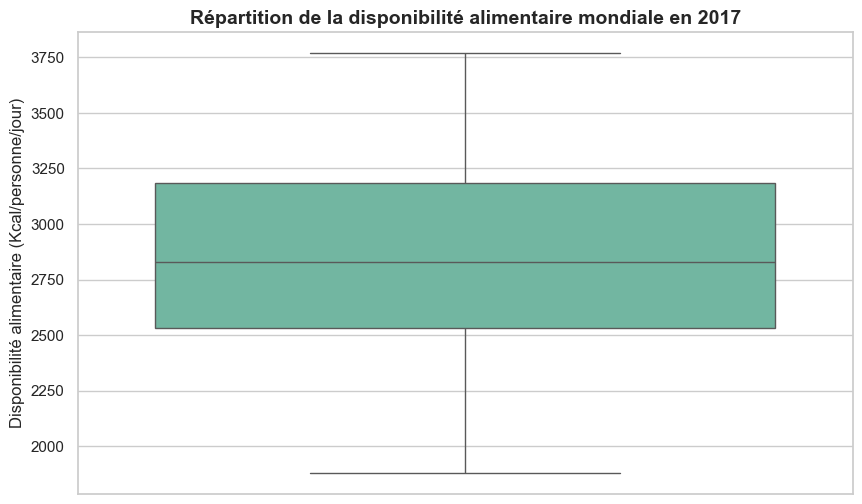

In [48]:
#Distribution de la disponibilité alimentaire sur tous les pays

sns.boxplot(y=dispo_alimentaire_kcal_personne_jour_par_pays['Disponibilité alimentaire (Kcal/personne/jour)'])

plt.title('Répartition de la disponibilité alimentaire mondiale en 2017')
plt.show()

In [49]:
dispo_alimentaire_kcal_personne_jour_par_pays['Disponibilité alimentaire (Kcal/personne/jour)'].describe()

count    174
mean    2847
std      439
min     1879
25%     2530
50%     2830
75%     3186
max     3770
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64

In [50]:
q1 = (
    dispo_alimentaire_kcal_personne_jour_par_pays['Disponibilité alimentaire (Kcal/personne/jour)']
    .quantile(0.25)
)
q3 = (
    dispo_alimentaire_kcal_personne_jour_par_pays['Disponibilité alimentaire (Kcal/personne/jour)']
    .quantile(0.75)
)

iqr = q3-q1

ecart_min = q1 - 1.5*iqr
ecart_max = q3 + 1.5*iqr

print(f'écart interquartile = {iqr}\nécart min = {ecart_min}\nécart max = {ecart_max}')

écart interquartile = 655.75
écart min = 1546.625
écart max = 4169.625


Résultat :

* Distribution globalement centrée autour de ~2830 kcal
* 50% des pays entre 2530 et 3186 kcal
* Dispersion modérée (IQR = 655.75)
* Variabilité totale (min/max) ~1900 kcal, influencée par les extrêmes

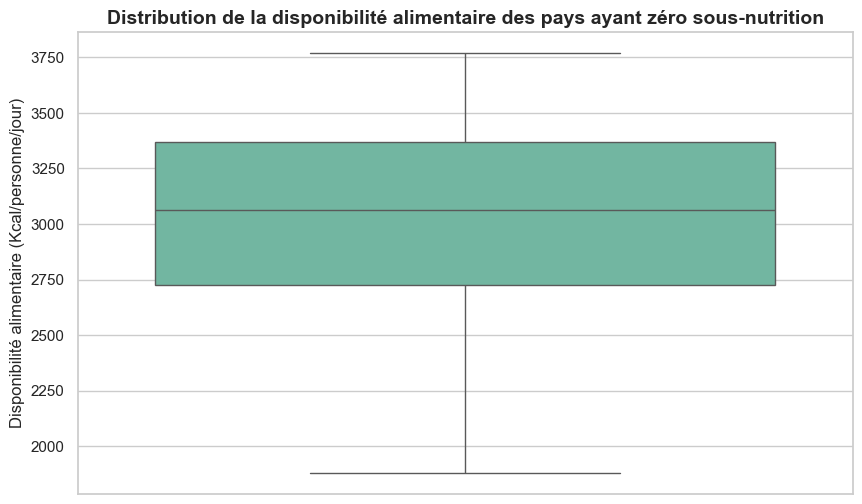

In [51]:
#Distribution de la disponibilité alimentaire des pays ayant zéro sous-nutrition (51%)
sns.boxplot(
    y=pays_zero_sous_nutrition['Disponibilité alimentaire (Kcal/personne/jour)']
    )
plt.title('Distribution de la disponibilité alimentaire des pays ayant zéro sous-nutrition')
plt.show()

In [52]:
pays_zero_sous_nutrition['Disponibilité alimentaire (Kcal/personne/jour)'].describe()

count     88
mean    3019
std      443
min     1879
25%     2723
50%     3062
75%     3368
max     3770
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64

In [53]:
q1 = (
    pays_zero_sous_nutrition['Disponibilité alimentaire (Kcal/personne/jour)']
    .quantile(0.25)
)
q3 = (
    pays_zero_sous_nutrition['Disponibilité alimentaire (Kcal/personne/jour)']
    .quantile(0.75)
)

iqr = q3-q1

ecart_min = q1 - 1.5*iqr
ecart_max = q3 + 1.5*iqr

print(f'écart interquartile = {iqr}\nécart min = {ecart_min}\nécart max = {ecart_max}')

écart interquartile = 644.75
écart min = 1756.125
écart max = 4335.125


Résultat :

* Distribution centrée autour de ~3060 kcal
* 50% des pays entre 2723 et 3368 kcal
* Dispersion très proche du global (IQR ≈ 644.75)
* Variabilité globale similaire (~1900 kcal)

Conclusion :

* Les deux distributions présentent une structure très similaire.
* Le groupe de pays sans sous-nutrition est légèrement décalé vers des niveaux de disponibilité plus élevés (médiane ~3060 vs ~2830 kcal).
* La dispersion est quasi identique entre les deux groupes.
* Il n’y a pas de séparation nette entre les populations.
* La disponibilité alimentaire seule ne permet donc pas de distinguer fortement les pays avec et sans sous-nutrition.

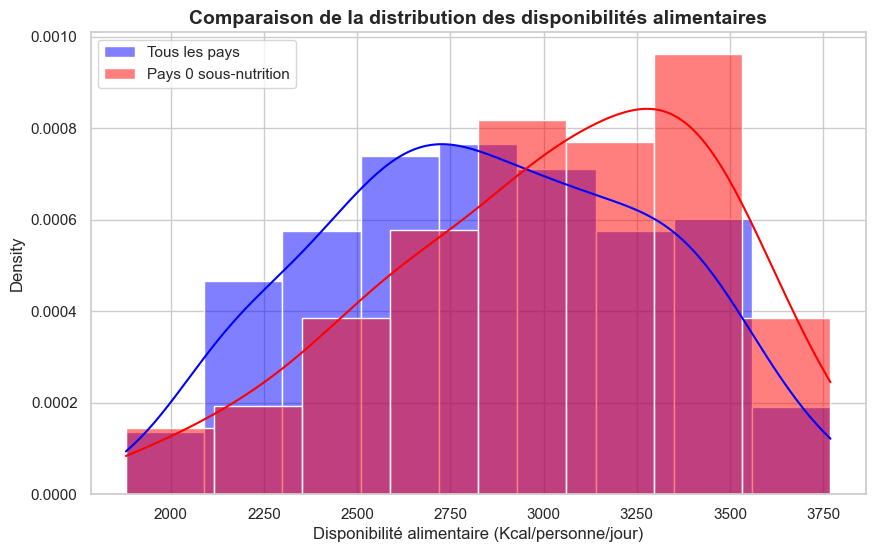

In [54]:
#comparaison structurelle
sns.histplot(
    dispo_alimentaire_kcal_personne_jour_par_pays['Disponibilité alimentaire (Kcal/personne/jour)'],
    color='blue',
    label='Tous les pays',
    kde=True,
    stat='density'
)

sns.histplot(
    pays_zero_sous_nutrition['Disponibilité alimentaire (Kcal/personne/jour)'],
    color='red',
    label='Pays 0 sous-nutrition',
    kde=True,
    stat='density'
)

plt.title('Comparaison de la distribution des disponibilités alimentaires')
plt.legend()
plt.show()

Interprétation :

* Les pays sans sous-nutrition présentent une disponibilité alimentaire globalement plus élevée que la population mondiale, avec une distribution décalée vers la droite (valeurs plus élevées). 
* Cependant, les deux distributions restent fortement chevauchantes, ce qui indique qu’il n’existe pas de séparation nette entre les deux groupes. 

Conclusion finale :

* **La sous-nutrition ne correspond pas à un seuil strict de disponibilité alimentaire**, mais à un ensemble de situations, où des niveaux plus élevés de disponibilité augmentent la probabilité d’absence de sous-nutrition sans en constituer un facteur déterminant unique.

______________

#### 4.1.3 Comment se comportent les pays aux niveaux extrêmes de disponibilité alimentaire ?

In [55]:
#pays ayant disponibilité alimentaire calorique faible

pays_kcal_faible = (
    population_sous_nutrition_dispo_kcal_2017[
        population_sous_nutrition_dispo_kcal_2017['Zone']
        .isin(top_10_pays_moins_kcal_dipo_par_personne['Zone'])
        ]
)
pays_kcal_faible.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)')

,Zone,Population,sous_nutrition,taux_sous_nutrition,Disponibilité alimentaire (Kcal/personne/jour)
131,République Centrafricaine,4596023,0,0,1879
170,Zambie,16853599,0,0,1924
97,Madagascar,25570512,10500000,41,2056
0,Afghanistan,36296113,10500000,29,2087
70,Haïti,10982366,5300000,48,2089
136,République Populaire Démocratique De Corée,25429825,12000000,47,2093
156,Tchad,15016753,5700000,38,2109
171,Zimbabwe,14236595,0,0,2113
120,Ouganda,41166588,0,0,2126
158,Timor-Leste,1243258,400000,32,2129


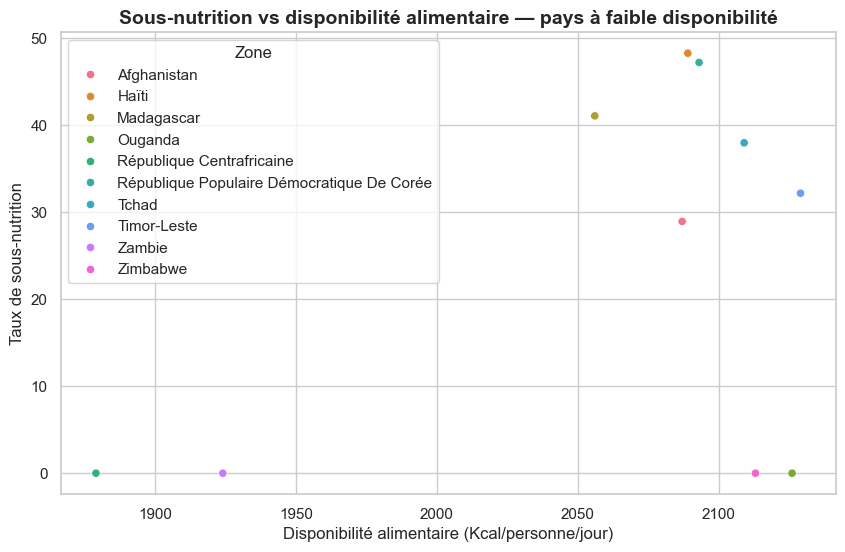

In [56]:
sns.scatterplot(
    data=pays_kcal_faible, 
    x='Disponibilité alimentaire (Kcal/personne/jour)',
    y='taux_sous_nutrition',
    hue='Zone')
plt.title('Sous-nutrition vs disponibilité alimentaire — pays à faible disponibilité')
plt.ylabel('Taux de sous-nutrition')
plt.show()

In [57]:
#Pays à faible disponibilité alimentaire
pays_kcal_faible[['taux_sous_nutrition', 'Disponibilité alimentaire (Kcal/personne/jour)']].agg(['min','max','mean','median'])

,taux_sous_nutrition,Disponibilité alimentaire (Kcal/personne/jour)
min,0,1879
max,48,2129
mean,24,2060
median,31,2091


Parmi les 10 pays ayant la plus faible disponibilité alimentaire, les niveaux de sous-nutrition sont très hétérogènes. Quatre pays présentent un taux de sous-nutrition nul, tandis que les autres affichent certains des taux les plus élevés de l'échantillon.

Conclusion :
* Une faible disponibilité alimentaire n'est donc pas systématiquement associée à une forte sous-nutrition.

In [58]:
#pays ayant disponibilité alimentaire calorique élevée
pays_kcal_eleve = (
    population_sous_nutrition_dispo_kcal_2017[
        population_sous_nutrition_dispo_kcal_2017['Zone']
        .isin(top_10_pays_plus_kcal_dipo_par_personne['Zone'])
        ]
)
pays_kcal_eleve.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=False)

,Zone,Population,sous_nutrition,taux_sous_nutrition,Disponibilité alimentaire (Kcal/personne/jour)
11,Autriche,8819901,0,0,3770
17,Belgique,11419748,0,0,3737
163,Turquie,81116450,0,0,3708
54,États-Unis D'Amérique,325084756,0,0,3682
80,Israël,8243848,0,0,3610
78,Irlande,4753279,0,0,3602
81,Italie,60673701,0,0,3578
95,Luxembourg,591910,0,0,3540
47,Égypte,96442591,4600000,5,3518
4,Allemagne,82658409,0,0,3503


In [59]:
#Pays à forte disponibilité alimentaire
pays_kcal_eleve['Disponibilité alimentaire (Kcal/personne/jour)'].agg(['min','max', 'mean','median'])

min      3503
max      3770
mean     3625
median   3606
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64

Parmi les 10 pays ayant la plus forte disponibilité alimentaire, neuf présentent un taux de sous-nutrition nul. Seule l'Égypte affiche un taux non nul (5%).

Conclusion :
* Une disponibilité alimentaire très élevée est donc presque systématiquement associée à l'absence de sous-nutrition. 

Conclusion :

Les situations extrêmes révèlent des comportements différents selon le niveau de disponibilité alimentaire.

Les pays à faible disponibilité alimentaire présentent des niveaux de sous-nutrition très variés, allant d'une absence de sous-nutrition à des situations critiques.

À l'inverse, les pays à très forte disponibilité alimentaire sont presque systématiquement associés à une absence de sous-nutrition.

Ces résultats suggèrent qu'une disponibilité alimentaire élevée constitue une condition favorable à l'absence de sous-nutrition, tandis qu'une faible disponibilité alimentaire ne conduit pas systématiquement à une forte sous-nutrition.

____________

### 4.2 Quelle la part de la sous-nutrition mondiale attribuable à chaque pays (pour 2017)


In [60]:
df = population_sous_nutrition_par_pays_2017.copy()

In [61]:
df['taux_global'] = (
    (df['sous_nutrition']
    /total_sous_nutrition
    )*100
).round(3)

top_10_part_sous_nutrition_mondiale_2017 = (
    df
    .sort_values(
        by='taux_global', 
        ascending=False)
        .head(10)
)

top_10_part_sous_nutrition_mondiale_2017

,Zone,Population,sous_nutrition,taux_sous_nutrition,taux_global
84,Inde,1338676785,190100000,14,35
136,Pakistan,207906209,24800000,12,5
85,Indonésie,264650963,23600000,9,4
128,Nigéria,190873244,22800000,12,4
16,Bangladesh,159685424,21500000,13,4
61,Éthiopie,106399924,21100000,20,4
144,Philippines,105172925,15700000,15,3
158,République-Unie De Tanzanie,54660339,13400000,25,3
157,République Populaire Démocratique De Corée,25429825,12000000,47,2
96,Kenya,50221142,11900000,24,2


In [62]:
top_10_part_sous_nutrition_mondiale_2017['taux_global'].sum()

np.float64(66.621)

* Ces 10 pays regroupent 66 % de la sous-nutrition mondiale.
* L’Inde en concentre 35 % à elle seule.

_________

## Conclusion

Résultats :

* La disponibilité calorique mondiale semble suffisante pour couvrir les besoins théoriques de la population.
* Pourtant, 7,1 % de la population mondiale reste sous-alimentée.
* D'importantes disparités existent entre pays concernant la disponibilité calorique.
* Ces disparités ne suffisent pas à expliquer à elles seules les taux de sous-nutrition observés.

Conclusion :

Les données suggèrent que la faim mondiale ne peut pas être expliquée uniquement par la quantité globale de calories disponibles. D'autres facteurs non présents dans le jeu de données comme l'accès économique, les inégalités, les conflits, les infrastructures ou la qualité nutritionnelle des aliments paraîtraient jouer un rôle non négligeable.